In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "2"


In [2]:
# Cargamos las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, ttest_ind
import pandas as pd
from itertools import combinations
from sklearn.metrics import silhouette_score
from itertools import combinations
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
import somnium
from somnium.core import SOM
from somnium.visualization import plot_components, plot_bmus, plot_umatrix
from somnium.visualization import _calculate_bmus_matrix, _plot_bmus
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import gower
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import shap
from boruta import BorutaPy

Hacemos una reducción de dimensionalidad con PCA

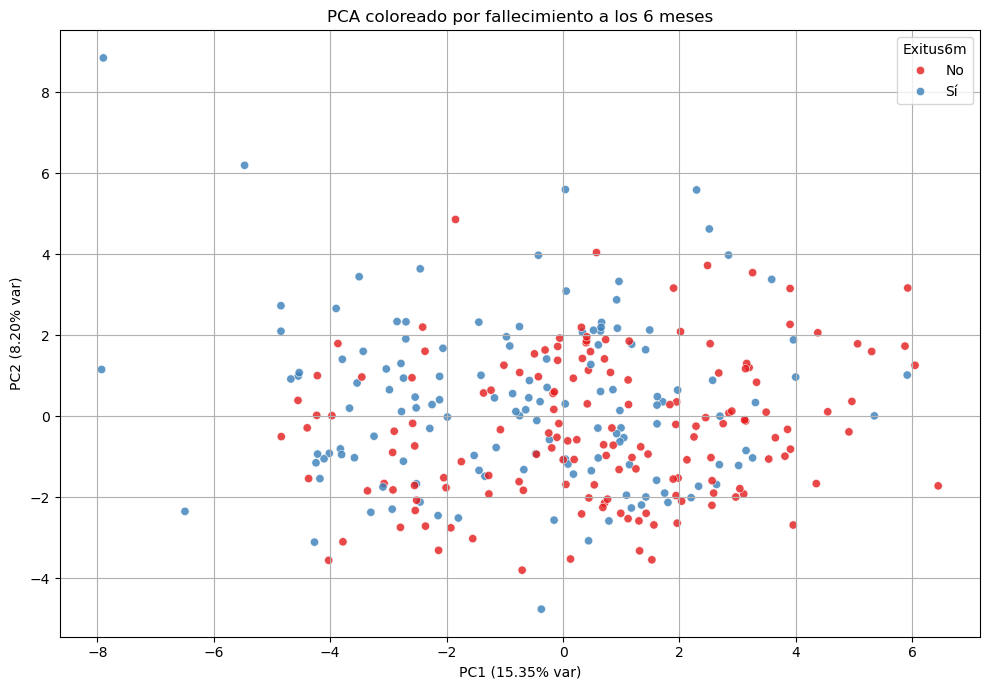

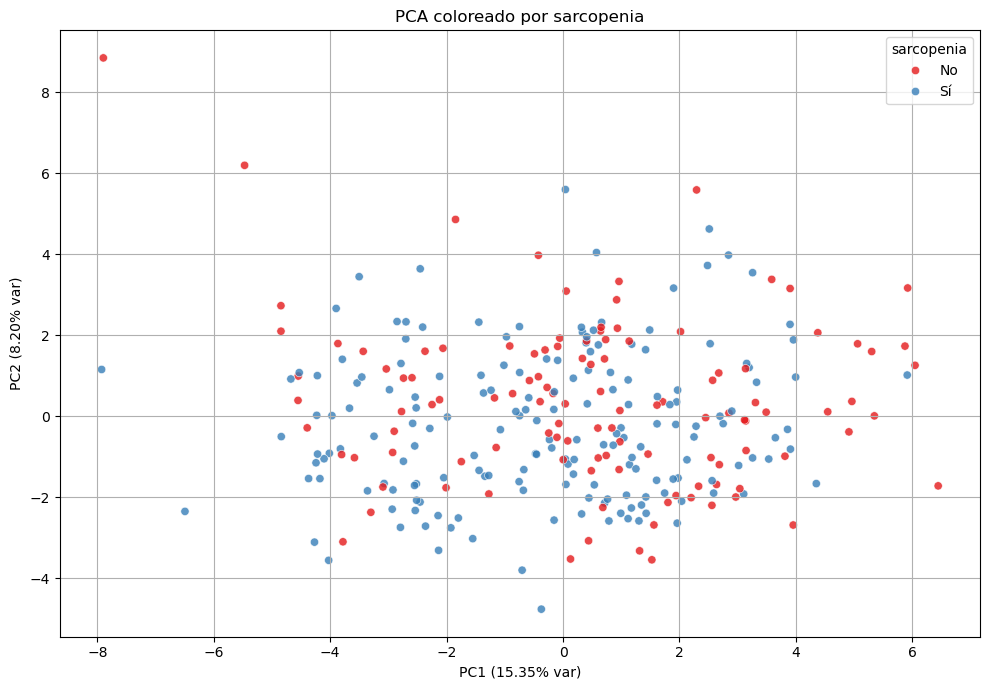

In [99]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicamos PCA a los datos preprocesados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_num_scal)

# Creamos un DataFrame con los dos componentes principales
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=data_num_scal.index)

# Coloreamos por la variable 'Exitus6m'
fallec6m = data_imputed_bool["Exitus6m"].loc[df_pca.index]
fallec6m = fallec6m.map({0: "No", 1: "Sí"}).astype("category")
plt.figure(figsize=(10, 7))
sns.scatterplot(x="PC1", y="PC2", data=df_pca, hue=fallec6m, palette="Set1", alpha=0.8)
plt.title("PCA coloreado por fallecimiento a los 6 meses")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.legend(title="Exitus6m")
plt.grid(True)
plt.tight_layout()
plt.show()

# Coloreamos por la variable sarcopenia
sarc = data_imputed_bool["sarcopenia"].loc[df_pca.index]
sarc = sarc.map({0: "No", 1: "Sí"}).astype("category")
plt.figure(figsize=(10, 7))
sns.scatterplot(x="PC1", y="PC2", data=df_pca, hue=sarc, palette="Set1", alpha=0.8)
plt.title("PCA coloreado por sarcopenia")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.legend(title="sarcopenia")
plt.grid(True)
plt.tight_layout()
plt.show()

Vemos que en el gráfico 2D solo se captura el 24% de la información total de los datos, lo que es bajo, por tanto, la información está distribuida en muchas dimensiones. Pero podemos ver que los pacientes que fallecieron a los 6 meses y los que no, no se agrupan.

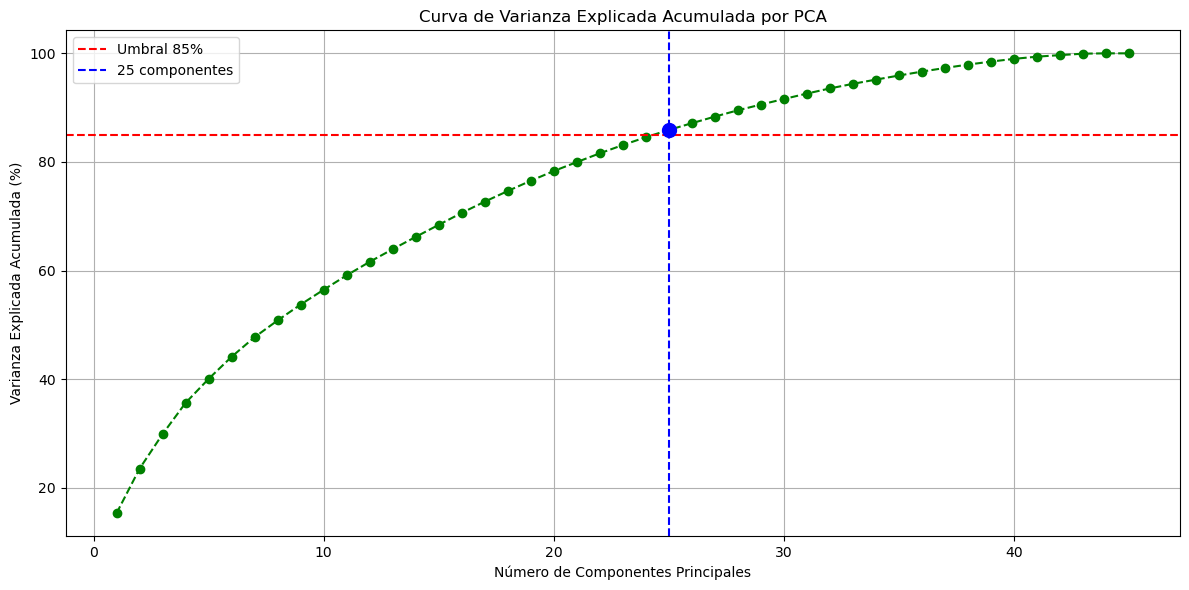

In [100]:
pca = PCA()
X_pca = pca.fit_transform(data_num_scal)
explained_var = pca.explained_variance_ratio_ * 100
cum_explained_var = np.cumsum(explained_var)
# Componentes con nombres
component_names = [f"PC{i+1}" for i in range(len(explained_var))]
expVar = pd.DataFrame(explained_var, columns=["Varianza Explicada"], index=component_names)
cumVar = pd.DataFrame(cum_explained_var, columns=["Varianza Explicada Acumulada"], index=component_names)
tabla_pca = pd.concat([expVar, cumVar], axis=1)

# Determinamos cuántos componentes se necesitan para alcanzar el 85%
umbral = 85
n_componentes_85 = np.argmax(cum_explained_var >= umbral) + 1

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(explained_var)+1), cum_explained_var, marker="o", linestyle="--", color="g")
plt.axhline(y=85, color='red', linestyle='--', label="Umbral 85%")
plt.axvline(x=n_componentes_85, color='blue', linestyle='--', label=f"{n_componentes_85} componentes")
plt.scatter(n_componentes_85, cum_explained_var[n_componentes_85-1], color='blue', s=100, zorder=5)
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Explicada Acumulada (%)")
plt.title("Curva de Varianza Explicada Acumulada por PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [101]:
pca = PCA(n_components=24)
X_pca = pca.fit_transform(data_num_scal)
df_pca_24 = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(24)], index=data_num_scal.index)

Proyección de los datos con t-SNE

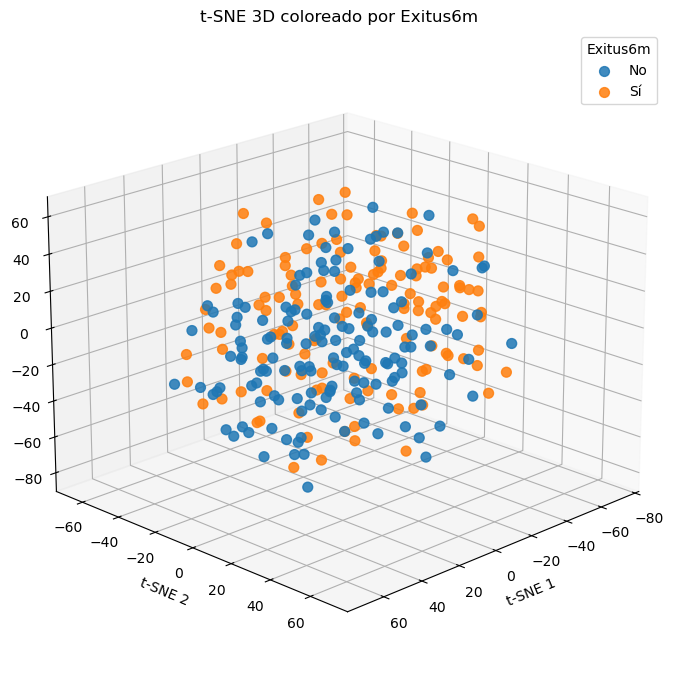

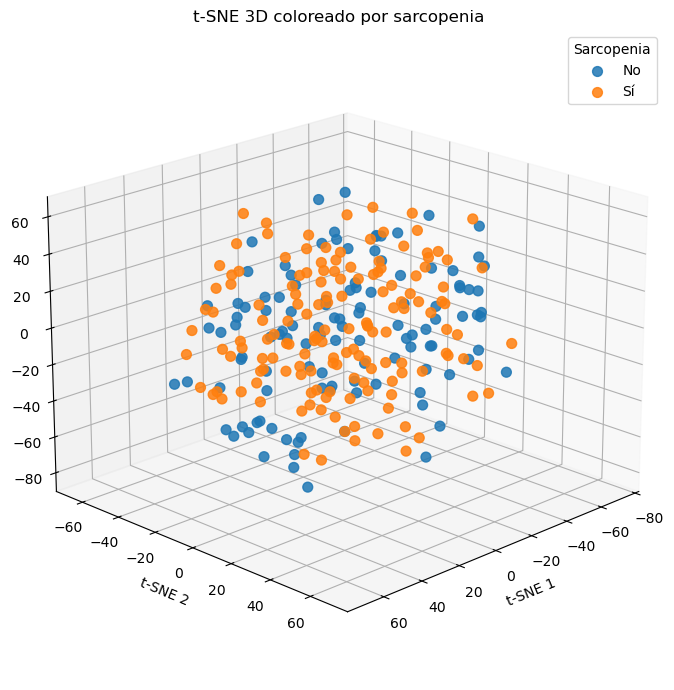

In [102]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

# Aplicamos t-SNE en 3 dimensiones
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=123
)

X_tsne = tsne.fit_transform(data_num_norm)

data_tsne_df = pd.DataFrame(
    X_tsne,
    columns=["TSNE1", "TSNE2", "TSNE3"]
)

# Añadimos las variables para colorear
data_tsne_df["Exitus6m"] = df["Exitus6m"].map({0: "No", 1: "Sí"}).astype("category")
data_tsne_df["sarcopenia"] = df["sarcopenia"].map({0: "No", 1: "Sí"}).astype("category")


# t-SNE 3D coloreado por Exitus6m
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for valor, grupo in data_tsne_df.groupby("Exitus6m", observed=False):
    ax.scatter(
        grupo["TSNE1"],
        grupo["TSNE2"],
        grupo["TSNE3"],
        label=valor,
        alpha=0.85,
        s=50
    )

ax.set_title("t-SNE 3D coloreado por Exitus6m")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
ax.legend(title="Exitus6m")
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()


# t-SNE 3D coloreado por sarcopenia
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for valor, grupo in data_tsne_df.groupby("sarcopenia", observed=False):
    ax.scatter(
        grupo["TSNE1"],
        grupo["TSNE2"],
        grupo["TSNE3"],
        label=valor,
        alpha=0.85,
        s=50
    )

ax.set_title("t-SNE 3D coloreado por sarcopenia")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
ax.legend(title="Sarcopenia")
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

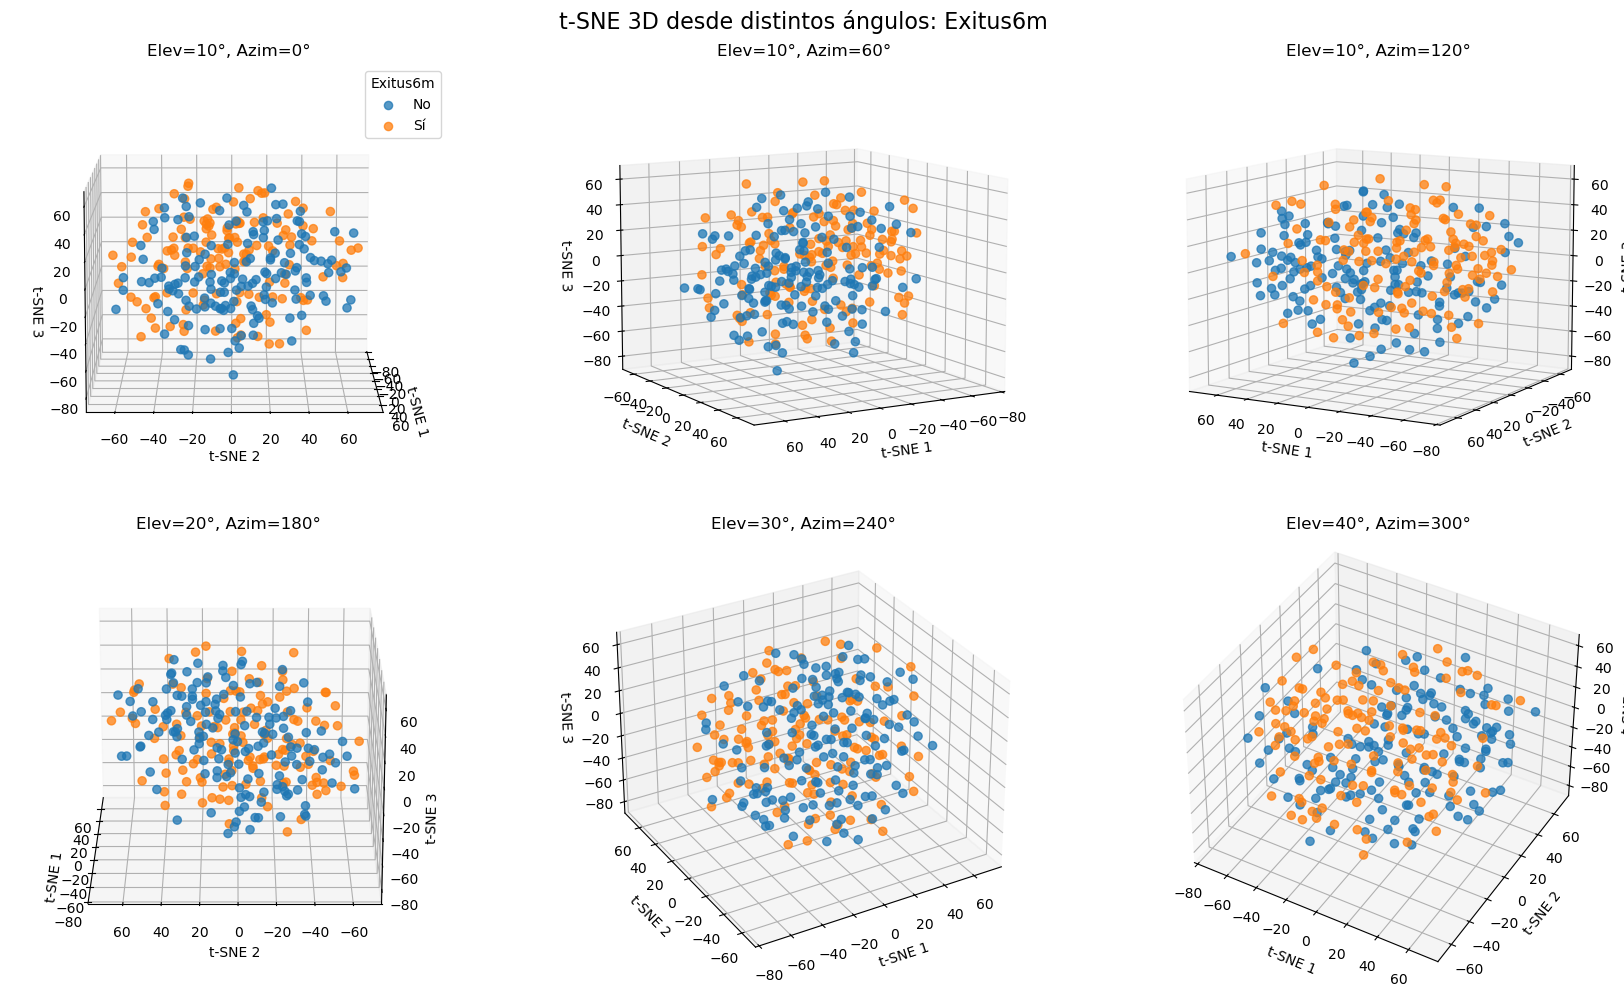

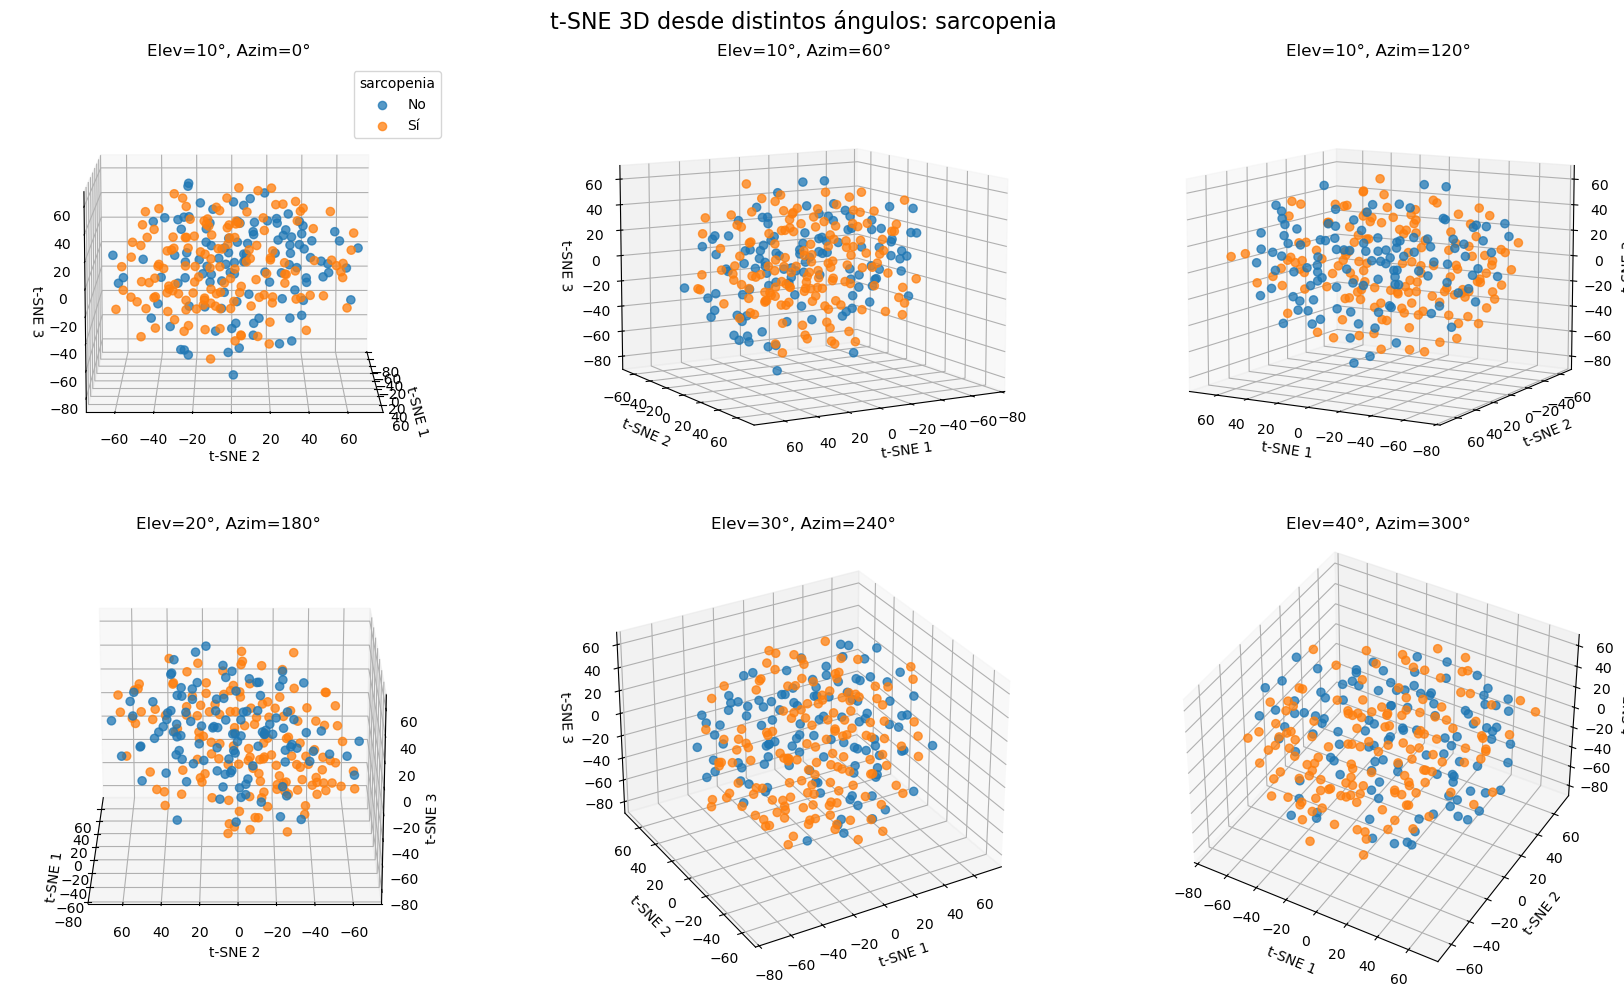

In [103]:
angulos = [
    (10, 0),
    (10, 60),
    (10, 120),
    (20, 180),
    (30, 240),
    (40, 300)
]

def mostrar_vistas_tsne_3d(columna, titulo):
    fig = plt.figure(figsize=(18, 10))

    for i, (elev, azim) in enumerate(angulos, start=1):
        ax = fig.add_subplot(2, 3, i, projection="3d")

        for valor, grupo in data_tsne_df.groupby(columna, observed=False):
            ax.scatter(
                grupo["TSNE1"],
                grupo["TSNE2"],
                grupo["TSNE3"],
                label=valor,
                alpha=0.75,
                s=35
            )

        ax.set_title(f"Elev={elev}°, Azim={azim}°")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_zlabel("t-SNE 3")
        ax.view_init(elev=elev, azim=azim)

        if i == 1:
            ax.legend(title=columna)

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()


mostrar_vistas_tsne_3d(
    "Exitus6m",
    "t-SNE 3D desde distintos ángulos: Exitus6m"
)

mostrar_vistas_tsne_3d(
    "sarcopenia",
    "t-SNE 3D desde distintos ángulos: sarcopenia"
)

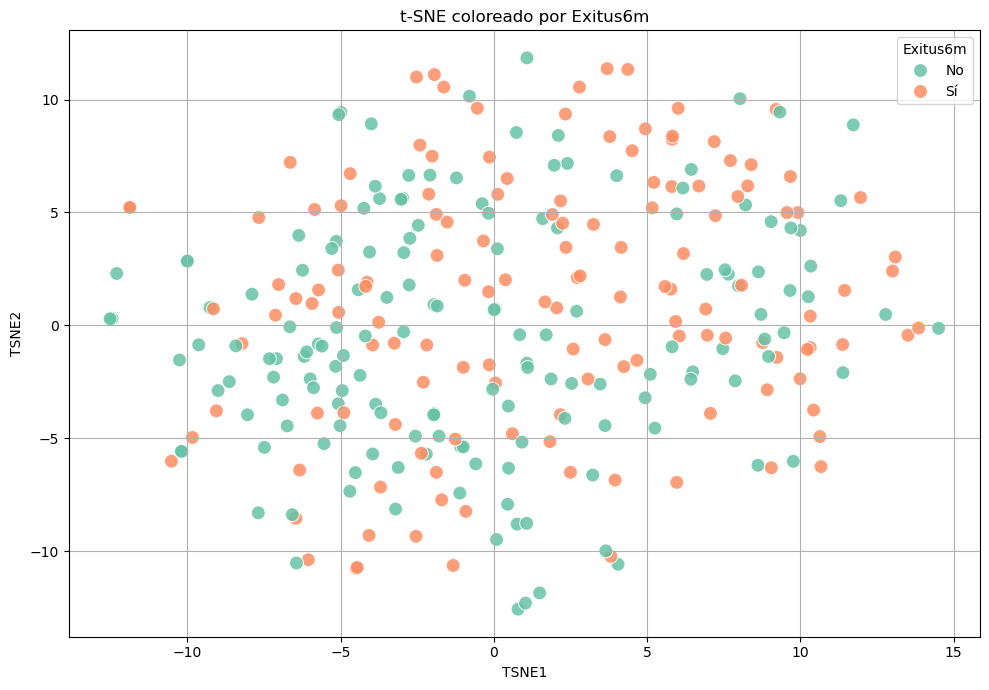

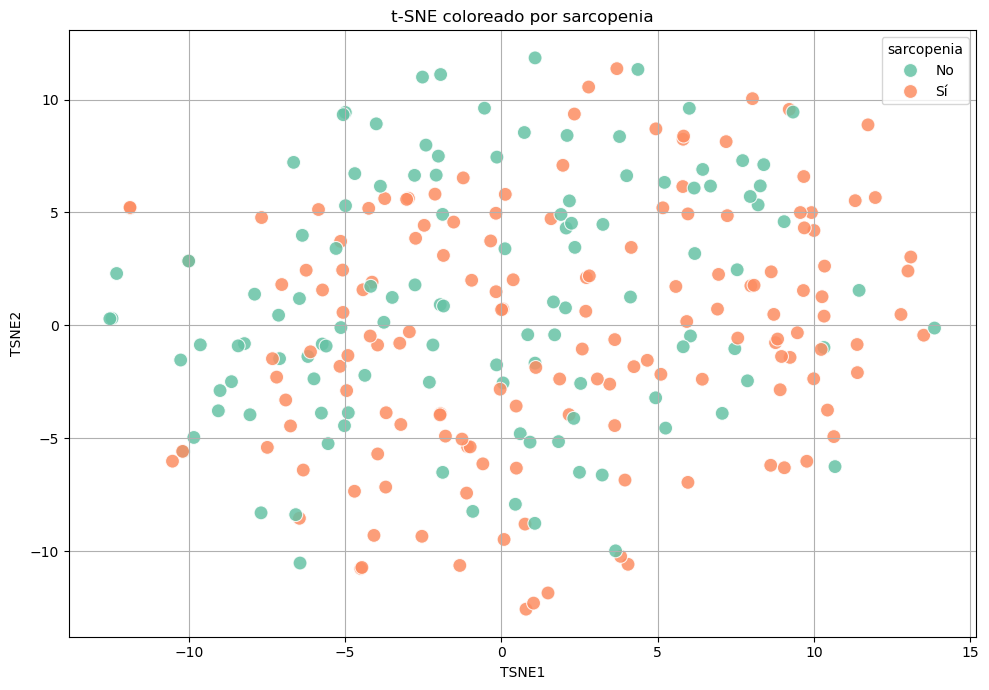

In [499]:
# Aplicamos tsne a lo datos normalizados 
tsne = TSNE(n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=123)
X_tsne = tsne.fit_transform(data_num_norm)
data_tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
# Coloreamos por Exitus6m
data_tsne_df["Exitus6m"] = df["Exitus6m"].map({0: "No", 1: "Sí"}).astype("category")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data_tsne_df, x="TSNE1", y="TSNE2", hue="Exitus6m", palette="Set2", alpha=0.85, s=100)
plt.title("t-SNE coloreado por Exitus6m")
plt.grid(True)
plt.tight_layout()
plt.show()

# Coloreamos por sarcopenia
data_tsne_df["sarcopenia"] = df["sarcopenia"].map({0: "No", 1: "Sí"}).astype("category")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data_tsne_df, x="TSNE1", y="TSNE2", hue="sarcopenia", palette="Set2", alpha=0.85, s=100)
plt.title("t-SNE coloreado por sarcopenia")
plt.grid(True)
plt.tight_layout()
plt.show()


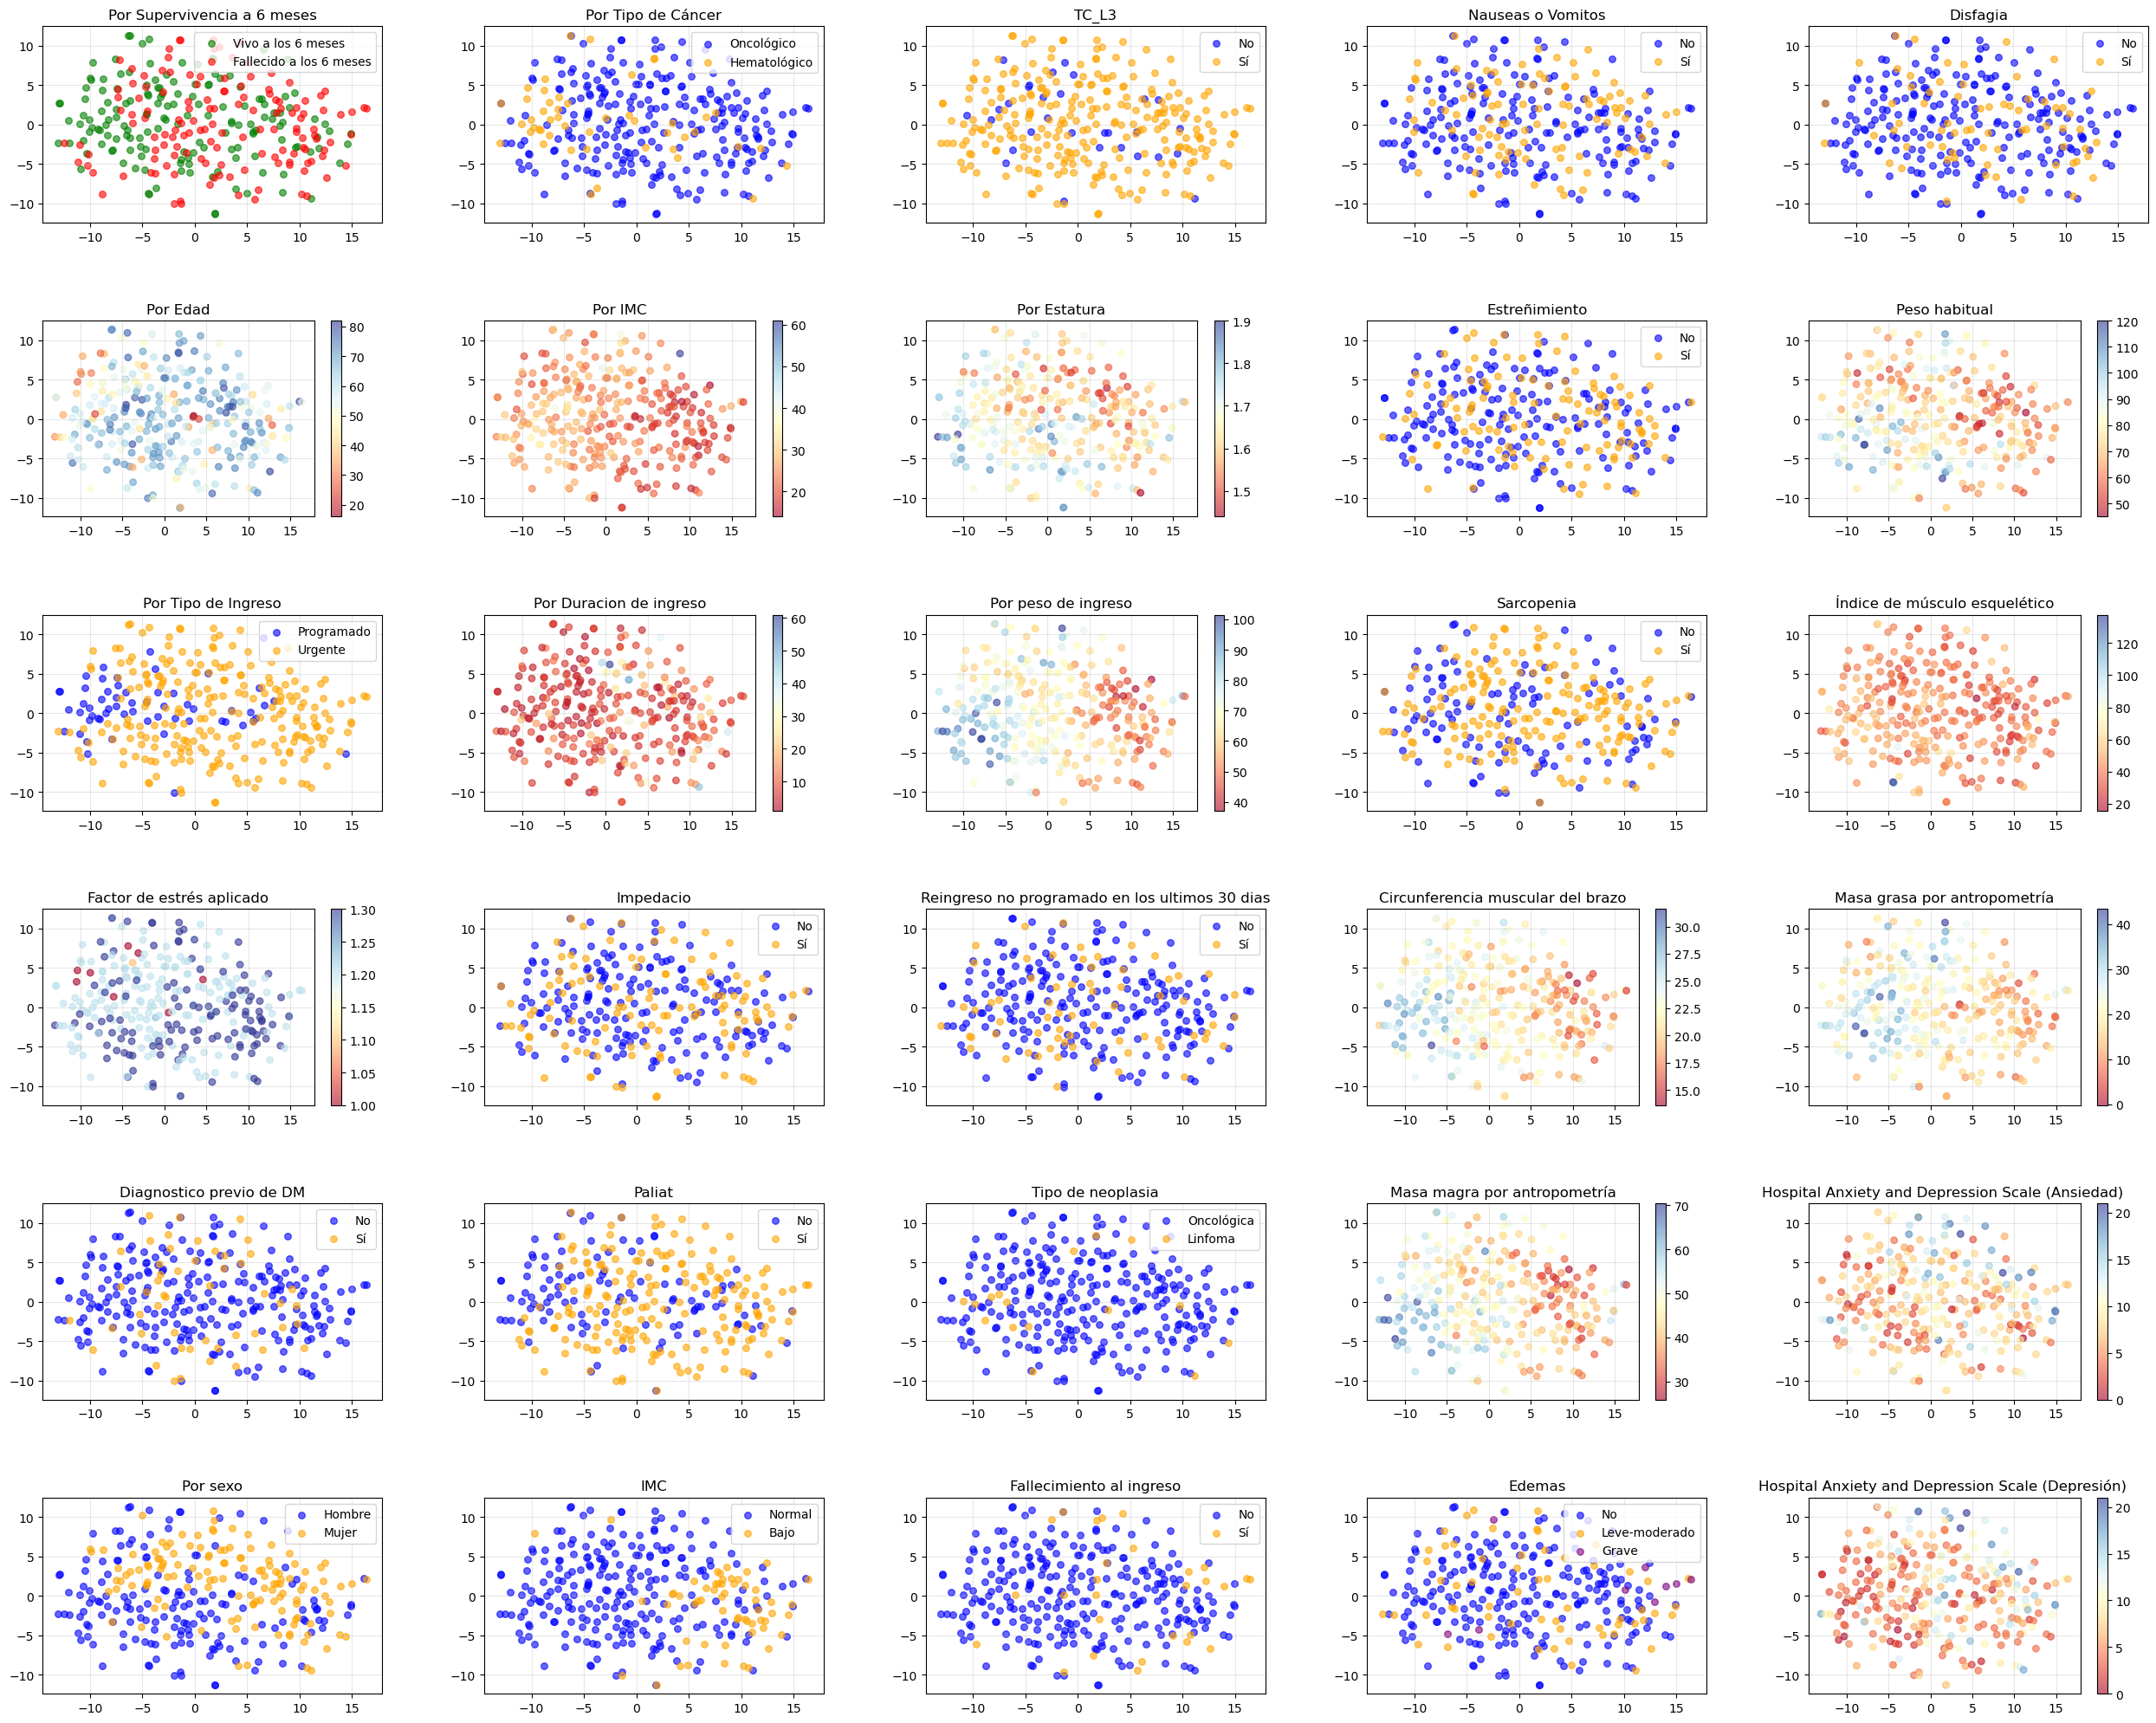

In [73]:
fig, axes = plt.subplots(6, 5, figsize=(25, 20))

# Por supervivencia
colors = ['green', 'red']
labels = ['Vivo a los 6 meses', 'Fallecido a los 6 meses']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Exitus6m'] == i
    axes[0,0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[0,0].set_title('Por Supervivencia a 6 meses')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
    
# Por tipo de cáncer
colors = ['blue', 'orange']
labels = ['Oncológico', 'Hematológico']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Onco_Hem'] == i
    axes[0,1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[0,1].set_title('Por Tipo de Cáncer')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# TC_L3
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['TC_L3'] == i
    axes[0,2].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[0,2].set_title('TC_L3')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Nauseas o vomitos
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['NauVom'] == i
    axes[0,3].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[0,3].set_title('Nauseas o Vomitos')
axes[0,3].legend()
axes[0,3].grid(True, alpha=0.3)

# Disfagia
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Disfag'] == i
    axes[0,4].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[0,4].set_title('Disfagia')
axes[0,4].legend()
axes[0,4].grid(True, alpha=0.3)

# Por edad (continuo)
scatter = axes[1,0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['Edad'], cmap='RdYlBu', alpha=0.6, s=30)
axes[1,0].set_title('Por Edad')
plt.colorbar(scatter, ax=axes[1,0])
axes[1,0].grid(True, alpha=0.3)

# Por IMC (continuo)
scatter = axes[1,1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['IMCm'], cmap='RdYlBu', alpha=0.6, s=30)
axes[1,1].set_title('Por IMC')
plt.colorbar(scatter, ax=axes[1,1])
axes[1,1].grid(True, alpha=0.3)

# Por Estatura (continuo)
scatter = axes[1,2].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['TallaM'], cmap='RdYlBu', alpha=0.6, s=30)
axes[1,2].set_title('Por Estatura')
plt.colorbar(scatter, ax=axes[1,2])
axes[1,2].grid(True, alpha=0.3)

# Estreñimiento
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Estreny'] == i
    axes[1,3].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[1,3].set_title('Estreñimiento')
axes[1,3].legend()
axes[1,3].grid(True, alpha=0.3)

# Peso habitual
scatter = axes[1,4].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['PesoHab'], cmap='RdYlBu', alpha=0.6, s=30)
axes[1,4].set_title('Peso habitual')
plt.colorbar(scatter, ax=axes[1,4])
axes[1,4].grid(True, alpha=0.3)

# Por tipo de ingreso
colors = ['blue', 'orange']
labels = ['Programado', 'Urgente']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['TipoIng'] == i
    axes[2,0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[2,0].set_title('Por Tipo de Ingreso')
axes[2,0].legend()
axes[2,0].grid(True, alpha=0.3)

# Por duracion de ingreso (continuo)
scatter = axes[2,1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['DuraIng'], cmap='RdYlBu', alpha=0.6, s=30)
axes[2,1].set_title('Por Duracion de ingreso')
plt.colorbar(scatter, ax=axes[2,1])
axes[2,1].grid(True, alpha=0.3)

# Por Peso de ingreso (continuo)
scatter = axes[2,2].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['PesIngE'], cmap='RdYlBu', alpha=0.6, s=30)
axes[2,2].set_title('Por peso de ingreso')
plt.colorbar(scatter, ax=axes[2,2])
axes[2,2].grid(True, alpha=0.3)

# sarcopenia
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['sarcopenia'] == i
    axes[2,3].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[2,3].set_title('Sarcopenia')
axes[2,3].legend()
axes[2,3].grid(True, alpha=0.3)

# Índice de músculo esquelético
scatter = axes[2,4].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['SMI'], cmap='RdYlBu', alpha=0.6, s=30)
axes[2,4].set_title('Índice de músculo esquelético')
plt.colorbar(scatter, ax=axes[2,4])
axes[2,4].grid(True, alpha=0.3)

# Factor de estrés aplicado
scatter = axes[3,0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['FactEstr'], cmap='RdYlBu', alpha=0.6, s=30)
axes[3,0].set_title('Factor de estrés aplicado')
plt.colorbar(scatter, ax=axes[3,0])
axes[3,0].grid(True, alpha=0.3)

# Prueba impedancia
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Impedan'] == i
    axes[3,1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[3,1].set_title('Impedacio')
axes[3,1].legend()
axes[3,1].grid(True, alpha=0.3)

# Reingreso no programado a los 30 dias 
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['ReNoPr30'] == i
    axes[3,2].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[3,2].set_title('Reingreso no programado en los ultimos 30 dias')
axes[3,2].legend()
axes[3,2].grid(True, alpha=0.3)

# Circunferencia muscular del brazo
scatter = axes[3,3].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['CMB'], cmap='RdYlBu', alpha=0.6, s=30)
axes[3,3].set_title('Circunferencia muscular del brazo')
plt.colorbar(scatter, ax=axes[3,3])
axes[3,3].grid(True, alpha=0.3)

# Masa grasa por antropometría
scatter = axes[3,4].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['masagras'], cmap='RdYlBu', alpha=0.6, s=30)
axes[3,4].set_title('Masa grasa por antropometría')
plt.colorbar(scatter, ax=axes[3,4])
axes[3,4].grid(True, alpha=0.3)

# Diagnostico previo de DM 
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['DM_0'] == i
    axes[4,0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[4,0].set_title('Diagnostico previo de DM')
axes[4,0].legend()
axes[4,0].grid(True, alpha=0.3)

# Paliat
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Paliat'] == i
    axes[4,1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[4,1].set_title('Paliat')
axes[4,1].legend()
axes[4,1].grid(True, alpha=0.3)

# Neoplasia
colors = ['blue', 'orange']
labels = ['Oncológica', 'Linfoma']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['OncoLinf'] == i
    axes[4,2].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[4,2].set_title('Tipo de neoplasia')
axes[4,2].legend()
axes[4,2].grid(True, alpha=0.3)

# Masa magra por antropometría
scatter = axes[4,3].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['masamagr'], cmap='RdYlBu', alpha=0.6, s=30)
axes[4,3].set_title('Masa magra por antropometría')
plt.colorbar(scatter, ax=axes[4,3])
axes[4,3].grid(True, alpha=0.3)

# Hospital Anxiety and Depression Scale (Ansiedad) 
scatter = axes[4,4].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['HADSA'], cmap='RdYlBu', alpha=0.6, s=30)
axes[4,4].set_title('Hospital Anxiety and Depression Scale (Ansiedad) ')
plt.colorbar(scatter, ax=axes[4,4])
axes[4,4].grid(True, alpha=0.3)

# Sexo
colors = ['blue', 'orange']
labels = ['Hombre', 'Mujer']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Sexo'] == i
    axes[5,0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[5,0].set_title('Por sexo')
axes[5,0].legend()
axes[5,0].grid(True, alpha=0.3)

# IMC_bajo
colors = ['blue', 'orange']
labels = ['Normal', 'Bajo']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['IMC_bajo'] == i
    axes[5,1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[5,1].set_title('IMC')
axes[5,1].legend()
axes[5,1].grid(True, alpha=0.3)

# Fallecimiento al ingreso
colors = ['blue', 'orange']
labels = ['No', 'Sí']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['ExituIng'] == i
    axes[5,2].scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                        c=color, label=label, alpha=0.6, s=30)
axes[5,2].set_title('Fallecimiento al ingreso')
axes[5,2].legend()
axes[5,2].grid(True, alpha=0.3)

# Edemas
colors = ['blue', 'orange', 'purple']
labels = ['No', 'Leve-moderado', 'Grave']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = data_imputed_df['Edemas'] == i
    axes[5,3].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=color, label=label, alpha=0.6, s=30)
axes[5,3].set_title('Edemas')
axes[5,3].legend()
axes[5,3].grid(True, alpha=0.3)

# Hospital Anxiety and Depression Scale (Depresión) 
scatter = axes[5,4].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=data_imputed_df['HADSD'], cmap='RdYlBu', alpha=0.6, s=30)
axes[5,4].set_title('Hospital Anxiety and Depression Scale (Depresión) ')
plt.colorbar(scatter, ax=axes[5,4])
axes[5,4].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

